In [1]:
TOP_DOMAINS = [
    "google.com","bing.com","yahoo.com","duckduckgo.com","yandex.ru","baidu.com",
    "facebook.com","instagram.com","x.com","twitter.com","whatsapp.com","reddit.com",
    "youtube.com","netflix.com","tiktok.com","twitch.tv",
    "amazon.com","ebay.com","paypal.com","aliexpress.com","etsy.com",
    "apple.com","microsoft.com","office.com","live.com","github.com",
    "stackoverflow.com","cloudflare.com","openai.com","chatgpt.com",
    "wikipedia.org","nytimes.com","bbc.com","weather.com",
    "linkedin.com","indeed.com",
    "spotify.com","canva.com","pinterest.com",
    "roblox.com","zoom.us","imdb.com","fandom.com",
    "gmail.com","mail.yahoo.com","outlook.com"
]

In [4]:
# ===============================================================
#      OFF-LINE  EVALUATION  OF  THE  SAVED  URL  MODEL
#      dataset csv must have columns: rec_id , url , label (1=phish,0=benign)
# ===============================================================
import json, time, sys, os, psutil, xgboost as xgb, pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve

# ─── 0. paths ────────────────────────────────────────────────────
ART_DIR   = Path("model_artifacts_url")      # folder created earlier
TEST_CSV  = "val_urls.csv"  # path to your csv

# ─── 1. load model + meta ───────────────────────────────────────
booster = xgb.Booster()
booster.load_model(ART_DIR / "url_xgb.json")

feature_order = json.load(open(ART_DIR / "url_features.json"))
thr           = float(open(ART_DIR / "url_threshold.txt").read().strip())

# memory footprint (model json + meta) in KB
model_bytes = (ART_DIR / "url_xgb.json").stat().st_size \
            + (ART_DIR / "url_features.json").stat().st_size
print(f"Model files: {model_bytes/1024:.1f} KB")

# ─── 2. URL feature extractor (MUST match training logic) ───────
import math, re
from urllib.parse import urlparse
import Levenshtein

# TOP_DOMAINS = set(json.load(open("top_domains.json"))) if Path("top_domains.json").exists() else set()
def entropy(s):
    if not s: return 0
    probs = [s.count(c)/len(s) for c in set(s)]
    return -sum(p*math.log2(p) for p in probs)

def _is_subdomain_of(host, parent):
    return host==parent or host.endswith("."+parent)

def extract_url_features_v3(url):
    try:
        parsed = urlparse(url)
        hostname = parsed.hostname or "".lower()
        tld = hostname.split('.')[-1] if '.' in hostname else ''
        subdomain = '.'.join(hostname.split('.')[:-2]) if len(hostname.split('.')) >= 3 else ''
        query = parsed.query or ''
        path = parsed.path or ''
        query_params = query.split('&') if query else []

        # Keyword checks and suspicious extensions for path.
        path_keywords = ["reset", "secure", "auth", "confirm"]
        suspicious_extensions = [".php", ".asp", ".cgi", ".jsp", ".exe"]

        features = {
            "url_length": len(url),
            "hostname_length": len(hostname),
            "subdomain_length": len(subdomain),
            "num_digits": sum(c.isdigit() for c in hostname),
            "num_hyphens": hostname.count('-'),
            "num_tokens": len(hostname.split('.')),
            "num_slashes": url.count('/'),
            "has_at_symbol": int('@' in url),
            "has_ip_address": int(re.fullmatch(r'^\d{1,3}(?:\.\d{1,3}){3}$', hostname) is not None),
            "is_free_hosting": int(any(fh in hostname for fh in ["weebly", "netlify", "000webhost", "github"])),
            "has_suspicious_port": int(parsed.port not in [None, 80, 443]),
            "has_exe_or_zip": int(bool(re.search(r'\.(exe|zip|rar)$', url.lower()))),
            "has_long_query": int(len(query) > 50),
            "has_keywords": int(any(k in url.lower() for k in ["login", "verify", "account", "secure", "update", "bank"])),
            "has_suspicious_tld": int(tld in ["tk", "ml", "ga", "cf", "gq"]),
            "high_entropy_domain": int(entropy(hostname) > 4.3),
            
            # Additional static features.
            "is_numeric_domain": int(re.fullmatch(r'^\d+$', hostname.replace('.', '').replace('-', '')) is not None),
            "domain_ends_with_number": int(re.search(r'\d$', hostname.split('.')[-2]) is not None) if len(hostname.split('.')) > 1 else 0,
            "path_contains_keywords": int(any(k in path.lower() for k in path_keywords)),
            "filename_suspicious_ext": int(any(path.lower().endswith(ext) for ext in suspicious_extensions)),
            "num_query_params": len(query_params)
        }
        
        # Extra features based on research.
        features["repeated_chars"] = int(bool(re.search(r'(.)\1{4,}', hostname)))
        features["is_punycode"] = int("xn--" in hostname)
        features["excess_subdomains"] = int(hostname.count('.') > 3)
        shorteners = ["bit.ly", "tinyurl.com", "goo.gl", "ow.ly", "t.co"]
        features["url_shortener"] = int(any(shortener in url for shortener in shorteners))
        features["non_https"] = int(parsed.scheme.lower() != "https")
        
        popular_domains = ["google.com", "paypal.com", "facebook.com", "amazon.com", "apple.com"]
        if popular_domains:
            distances = [Levenshtein.distance(hostname, pd) for pd in popular_domains]
            min_distance = min(distances)
        else:
            min_distance = float('inf')
        features["levenshtein_flag"] = int(min_distance <= 2)
        
        # Additional entropy and ratio features.
        features["path_entropy"] = entropy(path)
        features["query_entropy"] = entropy(query)
        features["ratio_digits_hostname"] = sum(c.isdigit() for c in hostname) / len(hostname) if hostname else 0
        special_chars_count = sum(1 for c in hostname if not c.isalnum() and c not in ".-")
        features["ratio_special_chars_hostname"] = special_chars_count / len(hostname) if hostname else 0
        tokens = hostname.split('.')
        features["unique_token_ratio"] = len(set(tokens)) / len(tokens) if tokens else 0
        features["has_many_subdirectories"] = int(path.count('/') > 3)
        features["contains_encoded_chars"] = int('%' in url)
        features["num_query_equals"] = query.count('=') if query else 0

        is_top = any(_is_subdomain_of(hostname, dom) for dom in TOP_DOMAINS)
        is_exact = hostname in TOP_DOMAINS
        features["is_top_domain"] = int(is_top)
        features["is_exact_top_domain"] = int(is_exact)
        return features
    
    except Exception as e:
        print("Error extracting features:", e)
        keys = [
            "url_length", "hostname_length", "subdomain_length", "num_digits", "num_hyphens",
            "num_tokens", "num_slashes", "has_at_symbol", "has_ip_address", "is_free_hosting",
            "has_suspicious_port", "has_exe_or_zip", "has_long_query", "has_keywords",
            "has_suspicious_tld", "high_entropy_domain", "is_numeric_domain",
            "domain_ends_with_number", "path_contains_keywords", "filename_suspicious_ext", "num_query_params",
            "repeated_chars", "is_punycode", "excess_subdomains", "url_shortener", "non_https", "levenshtein_flag",
            "path_entropy", "query_entropy", "ratio_digits_hostname", "ratio_special_chars_hostname",
            "unique_token_ratio", "has_many_subdirectories", "contains_encoded_chars", "num_query_equals"
        ]
        return {k: 0 for k in keys}

# ─── 3. load dataset & build matrix ─────────────────────────────
df = pd.read_csv(TEST_CSV)

X_list = []
for u in df["url"]:
    fd = extract_url_features_v3(u)                     # dict
    row = [fd.get(k, 0.0) for k in feature_order]       # list in saved order
    X_list.append(row)

X_mat = np.asarray(X_list, dtype=np.float32)
dtest  = xgb.DMatrix(X_mat, feature_names=feature_order)
y_true = df["label"].values

# ─── 4. inference & timing ─────────────────────────────────────
t0 = time.perf_counter()
proba = booster.predict(dtest)
latency_ms = (time.perf_counter() - t0)/len(df)*1000
pred  = (proba >= thr).astype(int)

# ─── 5. metrics  ────────────────────────────────────────────────
cm = confusion_matrix(y_true, pred, labels=[0,1])  # [[TN FP][FN TP]]
tn, fp, fn, tp = cm.ravel()
coverage      = tp / (tp+fn) if (tp+fn) else 0     # recall of phishing
error_rate    = fp / (fp+tn) if (fp+tn) else 0     # FPR
precision     = tp / (tp+fp) if (tp+fp) else 0
f1            = 2*precision*coverage/(precision+coverage+1e-9)

import pandas as pd

# put every URL into a decile based on predicted proba
bins   = np.linspace(0, 1, 11)          # 0-0.1, 0.1-0.2, … 0.9-1.0
labels = [f"{int(b*100)}–{int((b+0.1)*100)}%" for b in bins[:-1]]
bucket = pd.cut(proba, bins=bins, labels=labels, include_lowest=True)

# dataframe to aggregate
df_eval = pd.DataFrame({
    "bucket": bucket,
    "truth" : y_true,
    "pred"  : pred
})

g = df_eval.groupby("bucket", observed=True)

# individual aggregates
total  = g.size()
errors = g.apply(lambda d: (d.truth != d.pred).sum())
fp     = g.apply(lambda d: ((d.truth == 0) & (d.pred == 1)).sum())
fn     = g.apply(lambda d: ((d.truth == 1) & (d.pred == 0)).sum())

# assemble tidy table
err_tbl = pd.DataFrame({
    "total" : total,
    "errors": errors,
    "FP"    : fp,
    "FN"    : fn
}).fillna(0).astype(int)

# add percentages
err_tbl["error_rate%"] = (err_tbl.errors / err_tbl.total * 100).round(1)
err_tbl["FP_rate%"]    = (err_tbl.FP     / err_tbl.total * 100).round(1)
err_tbl["FN_rate%"]    = (err_tbl.FN     / err_tbl.total * 100).round(1)

print("\nError distribution by predicted phishing probability (deciles):")
print(err_tbl[["total","errors","error_rate%","FP_rate%","FN_rate%"]].to_string())

print("\nConfusion matrix [[TN FP][FN TP]]:\n", cm)
print(classification_report(y_true, pred, digits=3))
print(f"Coverage (TPR)       : {coverage:.3f}")
print(f"Error rate  (FPR)    : {error_rate:.3f}")
print(f"Precision            : {precision:.3f}")
print(f"F1 score             : {f1:.3f}")
print(f"Avg latency / URL    : {latency_ms:.2f} ms")
print(f"RAM after load (MB)  : {psutil.Process(os.getpid()).memory_info().rss/1024/1024:.1f}")


Model files: 4501.3 KB

Error distribution by predicted phishing probability (deciles):
         total  errors  error_rate%  FP_rate%  FN_rate%
bucket                                                 
0–10%     4108      22          0.5       0.0       0.5
10–20%     402      30          7.5       0.0       7.5
20–30%     337      62         18.4       0.0      18.4
30–40%     150      50         33.3       0.0      33.3
40–50%     121      46         38.0      33.1       5.0
50–60%     113      42         37.2      37.2       0.0
60–70%     127      30         23.6      23.6       0.0
70–80%     152      24         15.8      15.8       0.0
80–90%     245       9          3.7       3.7       0.0
90–100%   2244       4          0.2       0.2       0.0

Confusion matrix [[TN FP][FN TP]]:
 [[4850  149]
 [ 170 2830]]
              precision    recall  f1-score   support

           0      0.966     0.970     0.968      4999
           1      0.950     0.943     0.947      3000

    accuracy

/var/folders/qc/67jplx2s3fjbl7wv0d3cqrrr0000gn/T/ipykernel_97157/2343610521.py:173: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  errors = g.apply(lambda d: (d.truth != d.pred).sum())
/var/folders/qc/67jplx2s3fjbl7wv0d3cqrrr0000gn/T/ipykernel_97157/2343610521.py:174: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fp     = g.apply(lambda d: ((d.truth == 0) & (d.pred == 1)).sum())
/var/folders/qc/67jplx2s3fjbl

In [9]:
# ─── 6. eval low & high-confidence subsets ────────────────────────
# Define your two slices:
mask_high = proba >= 0.85
mask_low  = proba <= 0.2

def subset_stats(mask):
    size   = int(mask.sum())
    phish  = int(((y_true == 1) & mask).sum())
    benign = int(((y_true == 0) & mask).sum())
    if size:
        phish_rate  = phish  / size * 100
        benign_rate = benign / size * 100
    else:
        phish_rate = benign_rate = 0.0
    return size, phish_rate, benign_rate

h_count, h_prate, h_brate = subset_stats(mask_high)
l_count, l_prate, l_brate = subset_stats(mask_low)

print("\nHigh-confidence (proba ≥ 0.90):")
print(f"  count = {h_count} URLs")
print(f"  phishing rate = {h_prate:.1f}%")
print(f"  benign    rate = {h_brate:.1f}%")

print("\nLow-confidence  (proba ≤ 0.10):")
print(f"  count = {l_count} URLs")
print(f"  phishing rate = {l_prate:.1f}%")
print(f"  benign    rate = {l_brate:.1f}%")



High-confidence (proba ≥ 0.90):
  count = 2377 URLs
  phishing rate = 99.7%
  benign    rate = 0.3%

Low-confidence  (proba ≤ 0.10):
  count = 4510 URLs
  phishing rate = 1.2%
  benign    rate = 98.8%


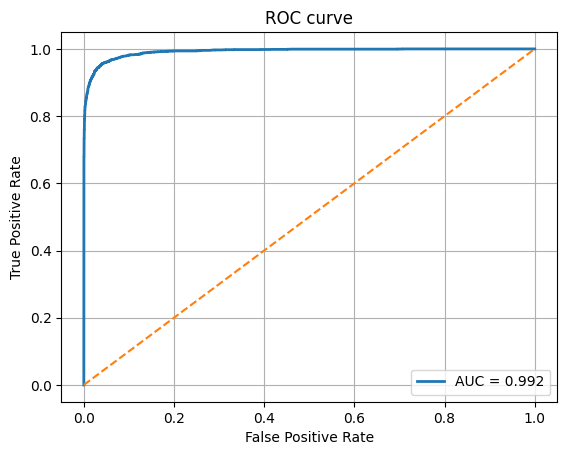

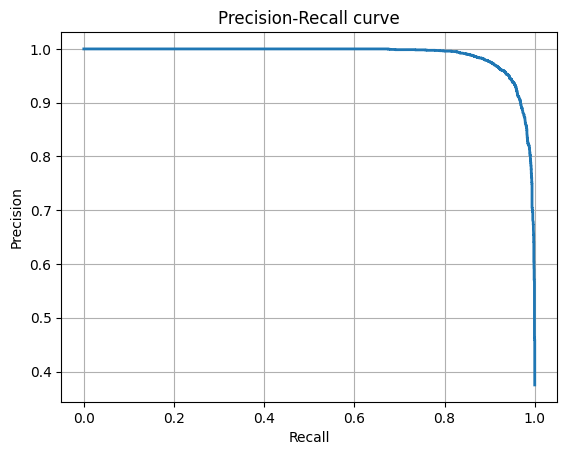

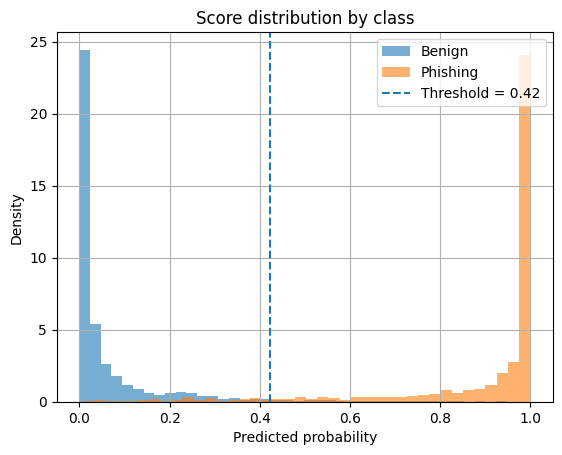

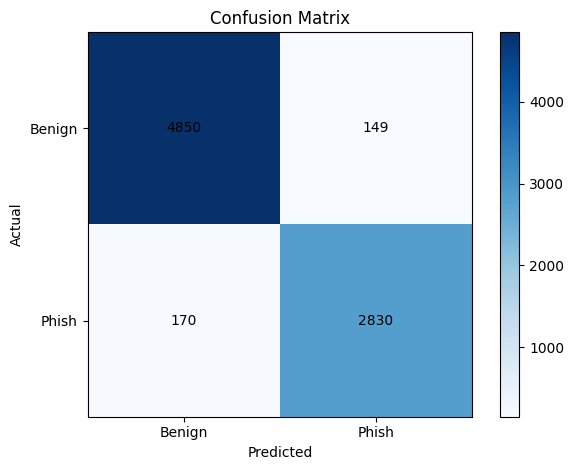

In [10]:
# ===============================================================
#   VISUAL DIAGNOSTICS   – ROC, PR, Score-hist & Confusion Matrix
#   (requires variables: y_true , proba , thr , cm   from previous cell)
# ===============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

# ---------- 1. ROC curve ----------
fpr, tpr, _ = roc_curve(y_true, proba)
roc_auc = roc_auc_score(y_true, proba)

plt.figure()
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], ls="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid(True)
plt.show()

# ---------- 2. Precision-Recall curve ----------
prec, reca, _ = precision_recall_curve(y_true, proba)
plt.figure()
plt.plot(reca, prec, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.grid(True)
plt.show()

# ---------- 3. Score distribution ----------
plt.figure()
plt.hist(proba[y_true == 0], bins=40, alpha=0.6, label="Benign", density=True)
plt.hist(proba[y_true == 1], bins=40, alpha=0.6, label="Phishing", density=True)
plt.axvline(thr, ls="--", label=f"Threshold = {thr:.2f}")
plt.xlabel("Predicted probability")
plt.ylabel("Density")
plt.title("Score distribution by class")
plt.legend()
plt.grid(True)
plt.show()

# ---------- 4. Confusion matrix heat-map ----------
plt.figure()
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Benign", "Phish"])
plt.yticks(tick_marks, ["Benign", "Phish"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()
